<a href="https://colab.research.google.com/github/iras-mpark/MLA1020/blob/main/week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [106]:
import numpy as np
import torch
from typing import Any


In [107]:
class Step:
  """Represents taking an `action`, incurring some `cost` and ending up in a new `state`."""
  def __init__(self, action: Any, cost: float, state: Any):
    self.action = action
    self.cost = cost
    self.state = state

In [108]:
class SearchProblem:
  """Formally and fully represents a search problem."""
  def start_state(self) -> Any:
    raise NotImplementedError
  def successors(self, state: Any) -> list[Step]:
    raise NotImplementedError
  def is_end(self, state: Any) -> bool:
    raise NotImplementedError

In [109]:
class Solution:
  """Represents a solution to a search problem (sequence of actions that produces a cost)."""
  steps: list[Step]
  cost: float
  def __init__(self, steps: list[Step]):
    self.steps = steps
    # The cost of a solution is the sum of the costs of the actions
    costs = [step.cost for step in steps]
    self.cost = sum(costs)

# UCS Example

### Diamond problem formulation

In [110]:
class DiamondSearchProblem(SearchProblem):
  def __init__(self):
    # state -> state -> cost
    self.graph = {
      "A": {"B": 1, "C": 100},
      "B": {"A": 1, "C": 1, "D": 100},
      "C": {"A": 100, "B": 1, "D": 1},
      "D": {"B": 100, "C": 1},
    }
  def start_state(self) -> str:
    return "A"

  def successors(self, state: str) -> list[Step]:
    return [
      Step(action=new_state, cost=cost, state=new_state) \
      for new_state, cost in self.graph[state].items()
    ]

  def is_end(self, state: str) -> bool:
    return state == "D"

# UCS Algorithm

In [111]:
class Backpointer:
  """For a state, record how we got to it."""
  def __init__(self, prev_state: Any, action: float, cost: float):
    self.prev_state = prev_state # Which state we came from
    self.action = action # Action we took from `prev_state`
    self.cost = cost # Cost of that action

In [112]:
import heapq

class PriorityQueue:
  """Data structure for supporting uniform cost search."""
  def __init__(self):
    self.DONE = -100000
    self.heap = []
    self.priorities = {}  # Map from state to priority
  def update(self, state: Any, new_priority: float) -> bool:
    """
    Insert `state` into the heap with priority `new_priority` if `state`
    isn't in the heap or `new_priority` is smaller than the existing
    priority.  Return whether the priority queue was updated.
    """
    old_priority = self.priorities.get(state)
    if old_priority is None or new_priority < old_priority:
      self.priorities[state] = new_priority
      heapq.heappush(self.heap, (new_priority, state))
      return True
    return False
  def remove_min(self):
    """Return (state with minimum priority, priority) or (None, None) if empty."""
    while len(self.heap) > 0:
      priority, state = heapq.heappop(self.heap)
      if self.priorities[state] == self.DONE:
        # Outdated priority, skip
        continue
      self.priorities[state] = self.DONE
      return state, priority
    # Nothing left...
    return None, None

In [113]:
def uniform_cost_search(problem: SearchProblem) -> tuple[Solution | None, int]:
  """
  Run Uniform Cost Search (UCS) on the specified search `problem`.
  Return the solution (sequence of steps) and the number of states explored.
  """
  # Frontier: states we've seen, still trying to figure out how the best way to get there
  # Priority represents the minimum cost to get there
  frontier = PriorityQueue()
  # For each state we've reached, backpointer tells us how we got there
  backpointers: dict[Any, Backpointer] = {}
  num_explored = 0
  # Add the start state
  start_state = problem.start_state()
  frontier.update(start_state, 0.0)
  while True:
    # Remove the state from the frontier with the lowest priority (theorem: priority = past_cost).
    state, past_cost = frontier.remove_min()
    if state is None and past_cost is None:
      return None, num_explored  # Found no solution
    num_explored += 1
    # Check if we've reached an end state; if so, extract solution.
    if problem.is_end(state):
      # Walk back the backpointers to get the actions
      steps = []
      while state != start_state:
        backpointer = backpointers[state]
        steps.insert(0, Step(backpointer.action, backpointer.cost, state))  # Prepend
        state = backpointer.prev_state  # Go back
      return Solution(steps=steps), num_explored
    # Expand from `state`, updating the frontier with each `new_state`
    for successor in problem.successors(state):
      if frontier.update(successor.state, past_cost + successor.cost):
          # We found better way to get to `successor.state` --> update backpointer!
          backpointers[successor.state] = Backpointer(prev_state=state, action=successor.action, cost=successor.cost)

In [114]:
problem = DiamondSearchProblem()
solution, num_explored = uniform_cost_search(problem)

In [115]:
print("Total state changes", len(solution.steps))

path_str = str(problem.start_state())
for step in solution.steps:
    path_str += " → " + str(step.state)
print(path_str)
print("Total cost:", solution.cost)

Total state changes 3
A → B → C → D
Total cost: 3


# A-star Examples

In [116]:
from typing import Any, Callable

Heuristic = Callable[[Any], float]

class ModifiedSearchProblem(SearchProblem):
  """A modified search problem where the costs are based on the `heuristic`."""
  def __init__(self, problem: SearchProblem, heuristic: Heuristic):
    self.problem = problem
    self.heuristic = heuristic

  def start_state(self) -> Any:
    return self.problem.start_state()
  def successors(self, state: Any) -> list[Step]:
    """Return the successors of `state`."""
    successors = []
    for successor in self.problem.successors(state):
      # Modify the cost using the heuristic
      modified_cost = successor.cost + self.heuristic(successor.state) - self.heuristic(state)
      successors.append(Step(successor.action, modified_cost, successor.state))
    return successors

  def is_end(self, state: Any) -> bool:
    return self.problem.is_end(state)

In [117]:
def astar_search(problem: SearchProblem, heuristic: Heuristic) -> tuple[Solution | None, int]:
  """Just wrap the problem and return the solution."""
  modified_problem = ModifiedSearchProblem(problem, heuristic)
  modified_solution, num_explored = uniform_cost_search(modified_problem)
  # The actions are correct but the costs are still the modified costs!
  # Need to get the original costs from the modified solution.
  state = problem.start_state()
  steps = []
  for step in modified_solution.steps:  # step: state ----> step.state
    modified_cost = step.cost
    # Recall: modified_cost = original_cost + heuristic(step.state) - heuristic(state)
    original_cost = modified_cost - heuristic(step.state) + heuristic(state)
    steps.append(Step(step.action, original_cost, step.state))
    state = step.state
  solution = Solution(steps=steps)
  return solution, num_explored

### Grid Search

In [118]:
class GridSearchProblem(SearchProblem):
  def __init__(self, *rows: list[str]):
    # Remove spaces (which are just for readability)
    self.rows = [row.replace(" ", "") for row in rows]
    self.num_rows = len(self.rows)
    self.num_cols = len(self.rows[0])

  def start_state(self) -> str:
    for r in range(self.num_rows):
      for c in range(self.num_cols):
        if self.rows[r][c] == "S":
          return (r, c)
    raise ValueError("No start state found")

  def is_valid(self, state: tuple[int, int]) -> bool:
    """Check if a state is valid."""
    r, c = state
    return 0 <= r < self.num_rows and \
            0 <= c < self.num_cols and \
            self.rows[r][c] != "#"

  def successors(self, state: tuple[int, int]) -> list[Step]:
    """Return the successors of a state (up, down, left, right)."""
    r, c = state
    successors = []
    if self.is_valid((r + 1, c)):
      successors.append(Step(action="down", cost=1, state=(r + 1, c)))
    if self.is_valid((r - 1, c)):
      successors.append(Step(action="up", cost=1, state=(r - 1, c)))
    if self.is_valid((r, c + 1)):
      successors.append(Step(action="right", cost=1, state=(r, c + 1)))
    if self.is_valid((r, c - 1)):
      successors.append(Step(action="left", cost=1, state=(r, c - 1)))
    return successors

  def is_end(self, state: tuple[int, int]) -> bool:
    """Check if a state is an end state."""
    r, c = state
    return self.rows[r][c] == "E"

In [119]:
problem = GridSearchProblem(
  # 0 1 2 3 4
  " S . . . .", # 0
  " # # # . #", # 1
  " . . . . .", # 2
  " . # # # #", # 3
  " . . . . E", # 4
)

relaxed_problem = GridSearchProblem(
  # 0 1 2 3 4
  " S . . . .", # 0
  " . . . . .", # 1
  " . . . . .", # 2
  " . . . . .", # 3
  " . . . . E", # 4
)

In [120]:
def future_cost_relaxed(state: tuple[int, int]) -> float:
  end_r = relaxed_problem.num_rows - 1
  end_c = relaxed_problem.num_cols - 1
  # Manhattan distance between (r, c) and (end_r, end_c)
  r, c = state
  dist = abs(end_r - r) + abs(end_c - c)
  return dist

In [121]:
solution, num_explored = uniform_cost_search(problem)
solution, num_explored = astar_search(problem, heuristic=future_cost_relaxed)

--- Uniform Cost Search ---
Total state changes: 14
Path: (0, 0) → (0, 1) → (0, 2) → (0, 3) → (1, 3) → (2, 3) → (2, 2) → (2, 1) → (2, 0) → (3, 0) → (4, 0) → (4, 1) → (4, 2) → (4, 3) → (4, 4)
Total cost: 14
Number of states explored: 17


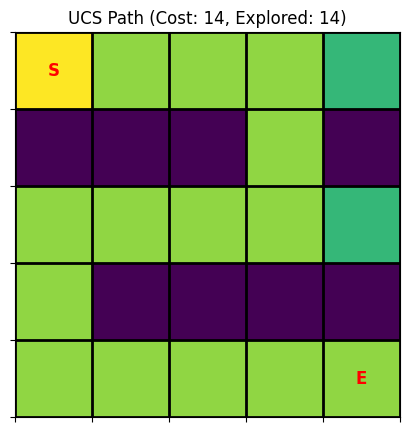


--- A* Search ---
Total state changes: 14
Path: (0, 0) → (0, 1) → (0, 2) → (0, 3) → (1, 3) → (2, 3) → (2, 2) → (2, 1) → (2, 0) → (3, 0) → (4, 0) → (4, 1) → (4, 2) → (4, 3) → (4, 4)
Total cost: 14
Number of states explored: 17


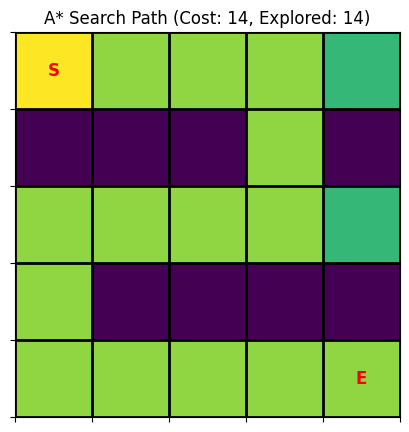

In [122]:
import matplotlib.pyplot as plt
import numpy as np

def plot_grid_path(problem: GridSearchProblem, solution: Solution | None, title: str):
  if not solution:
    print(f"No solution to plot for: {title}")
    return

  grid_rows = problem.rows
  num_rows = problem.num_rows
  num_cols = problem.num_cols

  # Create a numeric grid for plotting (0: empty, 1: obstacle, 2: start, 3: end, 4: path)
  plot_grid = np.zeros((num_rows, num_cols))
  for r in range(num_rows):
    for c in range(num_cols):
      char = grid_rows[r][c]
      if char == '#':
        plot_grid[r, c] = -1 # Obstacle
      elif char == 'S':
        plot_grid[r, c] = 0.5 # Start
      elif char == 'E':
        plot_grid[r, c] = 0.75 # End

  # Mark the path
  for i, step in enumerate(solution.steps):
    r, c = step.state
    if (r, c) != problem.start_state() and (r, c) != problem.is_end(step.state):
      plot_grid[r, c] = 0.25 # Path

  plt.figure(figsize=(num_cols, num_rows))
  plt.imshow(plot_grid, cmap='viridis', origin='upper')

  # Draw grid lines
  plt.xticks(np.arange(-.5, num_cols, 1), [])
  plt.yticks(np.arange(-.5, num_rows, 1), [])
  plt.grid(True, which='both', color='black', linestyle='-', linewidth=2)

  # Annotate start and end
  start_r, start_c = problem.start_state()
  end_r, end_c = next(filter(lambda r_c: grid_rows[r_c[0]][r_c[1]] == 'E', [(r,c) for r in range(num_rows) for c in range(num_cols)]))

  plt.text(start_c, start_r, 'S', ha='center', va='center', color='red', fontsize=12, fontweight='bold')
  plt.text(end_c, end_r, 'E', ha='center', va='center', color='red', fontsize=12, fontweight='bold')

  plt.title(f'{title} (Cost: {solution.cost if solution else "N/A"}, Explored: {len(solution.steps) if solution else "N/A"})')
  plt.show()


# Run UCS
ucs_solution, ucs_num_explored = uniform_cost_search(problem)

print("--- Uniform Cost Search ---")
if ucs_solution:
    print(f"Total state changes: {len(ucs_solution.steps)}")
    ucs_path_str = str(problem.start_state())
    for step in ucs_solution.steps:
        ucs_path_str += " → " + str(step.state)
    print(f"Path: {ucs_path_str}")
    print(f"Total cost: {ucs_solution.cost}")
    print(f"Number of states explored: {ucs_num_explored}")
else:
    print("No solution found for UCS.")
plot_grid_path(problem, ucs_solution, "UCS Path")

print("\n--- A* Search ---")
# Run A*
astar_solution, astar_num_explored = astar_search(problem, heuristic=future_cost_relaxed)

if astar_solution:
    print(f"Total state changes: {len(astar_solution.steps)}")
    astar_path_str = str(problem.start_state())
    for step in astar_solution.steps:
        astar_path_str += " → " + str(step.state)
    print(f"Path: {astar_path_str}")
    print(f"Total cost: {astar_solution.cost}")
    print(f"Number of states explored: {astar_num_explored}")
else:
    print("No solution found for A*.")
plot_grid_path(problem, astar_solution, "A* Search Path")

In [123]:
### 각자 환경을 더 복잡하게 만들어서 실행해보세요.

### LimitedTravelSearchProblem

In [124]:
class TravelSearchProblem(SearchProblem):
  """An instance of a `SearchProblem` where you try to go from 1 to n in the least time."""
  def __init__(self, num_locs: int):
    self.num_locs = num_locs
  def start_state(self) -> int:
    # Where we start (location 1)
    return 1
  def successors(self, state: int) -> list[Step]:
    """Return possible actions and their costs and resulting states."""
    successors = []
    if state + 1 <= self.num_locs:  # Stay within bounds?
      successors.append(Step(action="walk", cost=1, state=state + 1))
    if 2 * state <= self.num_locs:  # Stay within bounds?
      successors.append(Step(action="tram", cost=2, state=2 * state))
    return successors
  def is_end(self, state: int) -> bool:
    # Have we reached the destination?
    return state == self.num_locs

In [125]:
class TravelState:
    """Represents the state of the `LimitedTravelSearchProblem`, where you are at `loc` and have `tickets` left."""
    loc: int
    tickets: int

In [126]:
'''
class LimitedTravelSearchProblem(SearchProblem):
  def __init__(self, num_locs: int, starting_tickets: int):
    self.num_locs = num_locs
    self.starting_tickets = starting_tickets
  def start_state(self) -> TravelState:
    """Start at location 1 with `self.starting_tickets` tickets."""
    return TravelState(loc=1, tickets=self.starting_tickets)
  def successors(self, state: TravelState) -> list[Step]:
    """Return possible actions and their costs and resulting states."""
    successors = []
    if state.loc + 1 <= self.num_locs:  # Can always walk
      successors.append(Step(action="walk", cost=1, state=TravelState(loc=state.loc + 1, tickets=state.tickets)))
    if state.tickets > 0 and 2 * state.loc <= self.num_locs:  # Can only take the tram if we have tickets
      # Remember to decrement the number of tickets
      successors.append(Step(action="tram", cost=2, state=TravelState(loc=2 * state.loc, tickets=state.tickets - 1)))
    return successors
  def is_end(self, state: TravelState) -> bool:
    # Have we reached the destination?  Don't care about how many tickets we have
    return state.loc == self.num_locs
'''

'\nclass LimitedTravelSearchProblem(SearchProblem):\n  def __init__(self, num_locs: int, starting_tickets: int):\n    self.num_locs = num_locs\n    self.starting_tickets = starting_tickets\n  def start_state(self) -> TravelState:\n    """Start at location 1 with `self.starting_tickets` tickets."""\n    return TravelState(loc=1, tickets=self.starting_tickets)\n  def successors(self, state: TravelState) -> list[Step]:\n    """Return possible actions and their costs and resulting states."""\n    successors = []  \n    if state.loc + 1 <= self.num_locs:  # Can always walk\n      successors.append(Step(action="walk", cost=1, state=TravelState(loc=state.loc + 1, tickets=state.tickets)))  \n    if state.tickets > 0 and 2 * state.loc <= self.num_locs:  # Can only take the tram if we have tickets\n      # Remember to decrement the number of tickets\n      successors.append(Step(action="tram", cost=2, state=TravelState(loc=2 * state.loc, tickets=state.tickets - 1)))  \n    return successors\n  d

In [127]:
#problem = LimitedTravelSearchProblem(num_locs=5, starting_tickets=1)


In [128]:
def future_solution(state: Any, cache:dict[Any, Solution], num_explored) -> Solution:
  """Return the best solution from `state` (its cost is the future cost)."""
  # NEW: check cache first
  if state in cache:
    return cache[state]

  # Keep track of how many states we've explored
  num_explored += 1
  if problem.is_end(state):
    # Base: already at the end, don't need to take any more actions
    best_solution = Solution(steps=[])
  else:
    # Where can we go?
    successors = problem.successors(state)
    # Flesh each successor out recursively into a solution
    solutions = []
    for first_step in successors:
      future_steps = future_solution(first_step.state, cache, num_explored).steps
      solutions.append(Solution(steps=[first_step] + future_steps))
    # Pick the best one
    best_solution = min(solutions, key=lambda x: x.cost)
  # NEW: cache the solution
  cache[state] = best_solution
  return best_solution

In [129]:
def dynamic_programming(problem: SearchProblem) -> tuple[Solution | None, int, dict[Any, Solution]]:
    """Perform dynamic programming on `problem` to find the minimum cost solution."""
    # Keep track of how many states we've explored (time complexity)
    num_explored = 0

    # NEW: cache solutions for each state
    cache: dict[Any, Solution] = {}  # From state -> future solution
    # Helper function for the recurrence

    state = problem.start_state()
    solution = future_solution(state, cache, num_explored)
    return solution, num_explored, cache

In [132]:
relaxed_problem = TravelSearchProblem(num_locs=5)


_, num_explored_relaxed, future_costs_relaxed = dynamic_programming(relaxed_problem)
def heuristic(state: TravelState) -> float:
  # Note: problem states are (loc, tickets) but relaxed problem states are just loc
  state_relaxed = state.loc
  return future_costs_relaxed[state_relaxed].cost

TypeError: cannot unpack non-iterable int object